# Question 1(c): VAR-implied Campbell--Shiller coefficients

The data contain monthly observations of annual variables. Every eligible monthly row is retained as a starting observation, and the observation 12 rows ahead is the next annual observation. Thus, one application of $\Gamma$ represents a one-year transition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Steps 1-3: load the data, display an overview, create a date, and sort
df = pd.read_csv("EQ Dataset.csv")
df["date"] = pd.to_datetime(
    {"year": df["YEAR"], "month": df["MONTH"], "day": 1}
)
df = df.sort_values("date").reset_index(drop=True)
df.head()

,YEAR,MONTH,dp,dg,rf,re,date
0,1927,12,-3.143676,0.129874,0.053718,0.298791,1927-12-01
1,1928,1,-3.142009,0.105342,0.042354,0.283000,1928-01-01
2,1928,2,-3.117330,0.101963,0.048949,0.233187,1928-02-01
3,1928,3,-3.203713,0.077818,0.043086,0.307920,1928-03-01
4,1928,4,-3.242533,0.084212,0.042787,0.343425,1928-04-01


In [3]:
# Step 4: check completeness and verify that row offsets represent months
missing_values = df.isna().sum()
print("Missing values by column:")
print(missing_values)

month_number = 12 * df["date"].dt.year + df["date"].dt.month
if not month_number.diff().dropna().eq(1).all():
    raise ValueError("The data contain a gap in the monthly time index.")
if missing_values.any():
    raise ValueError("The data contain missing values.")

print(f"\nObservations: {len(df)}")
print(f"Sample: {df['date'].min():%Y-%m} to {df['date'].max():%Y-%m}")

Missing values by column:
YEAR     0
MONTH    0
dp       0
dg       0
rf       0
re       0
date     0
dtype: int64

Observations: 1129
Sample: 1927-12 to 2021-12


In [4]:
# Steps 5-6: calculate the mean log dividend-price ratio and kappa
bar_dp = df["dp"].mean()
kappa = 1 / (1 + np.exp(bar_dp))

print(f"bar_dp = {bar_dp:.9f}")
print(f"kappa  = {kappa:.9f}")

bar_dp = -3.294161665
kappa  = 0.964227978


## Estimate the annual-transition VAR

Let $z_t = [\Delta d_t, r_{e,t}, dp_t]'$. The three equations use the same regressors $[1,z_t']$ but are estimated separately. The dependent observations are shifted forward by 12 monthly rows.

In [5]:
# Steps 7-9: form z_t and z_{t+12}, then estimate three OLS equations
z_names = ["dg", "re", "dp"]
annual_step = 12
z_t = df[z_names].iloc[:-annual_step].reset_index(drop=True)
z_t12 = df[z_names].iloc[annual_step:].reset_index(drop=True)

def ols_with_intercept(y, X):
    """Return OLS coefficients for y on an intercept and columns of X."""
    design = np.column_stack((np.ones(len(X)), np.asarray(X)))
    return np.linalg.lstsq(design, np.asarray(y), rcond=None)[0]

Gamma_0 = np.empty(3)
Gamma = np.empty((3, 3))

for equation, dependent_variable in enumerate(z_names):
    coefficients = ols_with_intercept(z_t12[dependent_variable], z_t)
    Gamma_0[equation] = coefficients[0]
    Gamma[equation, :] = coefficients[1:]

print(f"Annual-transition observations per equation: {len(z_t)}")
print("\nIntercept vector Gamma_0:")
display(pd.Series(Gamma_0, index=z_names, name="intercept"))
print("Slope matrix Gamma:")
display(pd.DataFrame(Gamma, index=z_names, columns=z_names))

Annual-transition observations per equation: 1117

Intercept vector Gamma_0:


dg   -0.319240
re    0.303511
dp   -0.482464
Name: intercept, dtype: float64

Slope matrix Gamma:


,dg,re,dp
dg,0.090888,0.278972,-0.095682
re,-0.140535,0.010556,0.072668
dp,0.241270,0.274756,0.862585


In [6]:
# Step 10: regress each element of z_t on dp_t, with an intercept
b_z_intercepts = np.empty(3)
b_z = np.empty((3, 1))

for equation, dependent_variable in enumerate(z_names):
    coefficients = ols_with_intercept(df[dependent_variable], df[["dp"]])
    b_z_intercepts[equation] = coefficients[0]
    b_z[equation, 0] = coefficients[1]

b_z_table = pd.DataFrame(
    {"intercept": b_z_intercepts, "slope_on_dp": b_z.ravel()},
    index=z_names,
)
b_z_table

,intercept,slope_on_dp
dg,6.371475e-02,0.014847
re,-4.799845e-01,-0.165646
dp,3.209729e-16,1.000000


## VAR-implied coefficients by horizon

For each $H=1,\ldots,20$, compute

$$b_{re}^{(H)}=\mathbf{1}_{re}'(\Gamma-\kappa^H\Gamma^{H+1})(I-\kappa\Gamma)^{-1}b_z,$$

$$b_{dg}^{(H)}=-\mathbf{1}_{dg}'(\Gamma-\kappa^H\Gamma^{H+1})(I-\kappa\Gamma)^{-1}b_z,$$

and $b_{dp}^{(H)}=1-b_{dg}^{(H)}-b_{re}^{(H)}$.

In [7]:
# Steps 11-14: define selectors, calculate coefficients, and check adding up
selector_dg = np.array([[1.0], [0.0], [0.0]])
selector_re = np.array([[0.0], [1.0], [0.0]])
identity = np.eye(3)

# Solve the linear system instead of explicitly forming the matrix inverse.
resolvent_times_bz = np.linalg.solve(identity - kappa * Gamma, b_z)

b_re_list = []
b_dg_list = []
b_dp_list = []

for H in range(1, 21):
    weighted_transition_sum = (
        Gamma
        - (kappa ** H) * np.linalg.matrix_power(Gamma, H + 1)
    ) @ resolvent_times_bz

    b_re_H = float((selector_re.T @ weighted_transition_sum).item())
    b_dg_H = -float((selector_dg.T @ weighted_transition_sum).item())
    b_dp_H = 1.0 - b_dg_H - b_re_H

    b_re_list.append(b_re_H)
    b_dg_list.append(b_dg_H)
    b_dp_list.append(b_dp_H)

results = pd.DataFrame({
    "H": range(1, 21),
    "b_re": b_re_list,
    "b_dg": b_dg_list,
    "b_dp": b_dp_list,
})
results["coefficient_sum"] = results[["b_re", "b_dg", "b_dp"]].sum(axis=1)

if not np.allclose(results["coefficient_sum"], 1.0, atol=1e-12, rtol=0):
    raise AssertionError("The VAR-implied coefficients do not add to one.")

print("All coefficient sums equal one within numerical tolerance.")
results

All coefficient sums equal one within numerical tolerance.


,H,b_re,b_dg,b_dp,coefficient_sum
0,1,0.068833,0.140543,0.790623,1.0
1,2,0.146081,0.210058,0.643861,1.0
2,3,0.203100,0.257010,0.539891,1.0
3,4,0.249279,0.297449,0.453271,1.0
4,5,0.288156,0.331927,0.379917,1.0
5,6,0.320809,0.360811,0.318380,1.0
6,7,0.348158,0.384979,0.266864,1.0
7,8,0.371061,0.405218,0.223720,1.0
8,9,0.390245,0.422172,0.187583,1.0
9,10,0.406313,0.436373,0.157313,1.0


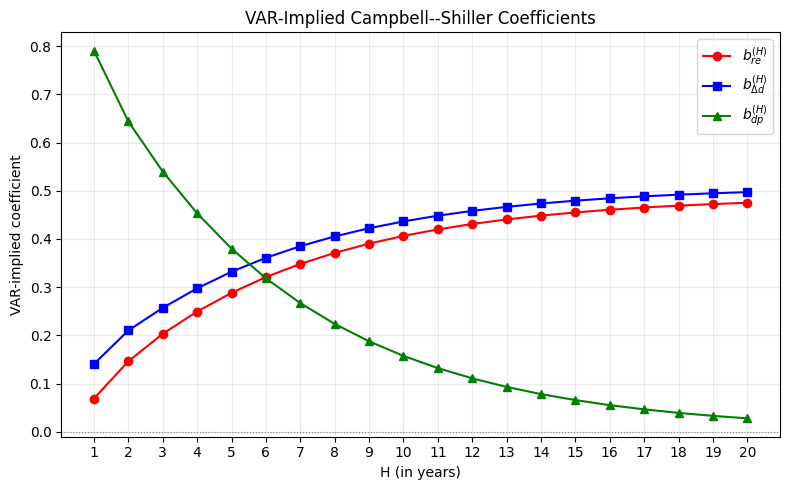

In [8]:
# Step 15: plot and save the VAR-implied coefficients
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results["H"], results["b_re"], color="red", marker="o", label=r"$b_{re}^{(H)}$")
ax.plot(results["H"], results["b_dg"], color="blue", marker="s", label=r"$b_{\Delta d}^{(H)}$")
ax.plot(results["H"], results["b_dp"], color="green", marker="^", label=r"$b_{dp}^{(H)}$")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set(
    xlabel="H (in years)",
    ylabel="VAR-implied coefficient",
    title="VAR-Implied Campbell--Shiller Coefficients",
)
ax.set_xticks(range(1, 21))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig("figures/q1c_var_implied_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()